![Strathmore.png](attachment:Strathmore.png)

<p style="text-align: center;"><font size="4">Samuel Irungu Kigotho</font></p>
<p style="text-align: center;"><font size="4">Adm No: 169124</font></p>
<p style="text-align: center;"><font size="4">Assigment: Ensemble Methods</font></p>
<p style="text-align: center;"><font size="4">DSA 8401: Applied Machine Learning</font></p>
<p style="text-align: center;"><font size="4">Master in Data Science and Analytic</font></p>

**1. Import the dataset using Pandas. Does it have missings?**

In [6]:
# import  libraries
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import cross_val_score

In [7]:
# import the dataset
fetal_health_df = pd.read_csv("fetal_health.csv")

In [8]:
# Check the dataset to get an overview of the attributes
fetal_health_df.head()

,baseline value,accelerations,fetal_movement,uterine_contractions,light_decelerations,severe_decelerations,prolongued_decelerations,abnormal_short_term_variability,mean_value_of_short_term_variability,percentage_of_time_with_abnormal_long_term_variability,...,histogram_min,histogram_max,histogram_number_of_peaks,histogram_number_of_zeroes,histogram_mode,histogram_mean,histogram_median,histogram_variance,histogram_tendency,fetal_health
0,120.0,0.000,0.0,0.000,0.000,0.0,0.0,73.0,0.5,43.0,...,62.0,126.0,2.0,0.0,120.0,137.0,121.0,73.0,1.0,2.0
1,132.0,0.006,0.0,0.006,0.003,0.0,0.0,17.0,2.1,0.0,...,68.0,198.0,6.0,1.0,141.0,136.0,140.0,12.0,0.0,1.0
2,133.0,0.003,0.0,0.008,0.003,0.0,0.0,16.0,2.1,0.0,...,68.0,198.0,5.0,1.0,141.0,135.0,138.0,13.0,0.0,1.0
3,134.0,0.003,0.0,0.008,0.003,0.0,0.0,16.0,2.4,0.0,...,53.0,170.0,11.0,0.0,137.0,134.0,137.0,13.0,1.0,1.0
4,132.0,0.007,0.0,0.008,0.000,0.0,0.0,16.0,2.4,0.0,...,53.0,170.0,9.0,0.0,137.0,136.0,138.0,11.0,1.0,1.0


In [9]:
# check the data points in the dataset
fetal_health_df.shape

(2126, 22)

In [10]:
# check for missing values 
fetal_health_df.isnull().sum()

baseline value                                            0
accelerations                                             0
fetal_movement                                            0
uterine_contractions                                      0
light_decelerations                                       0
severe_decelerations                                      0
prolongued_decelerations                                  0
abnormal_short_term_variability                           0
mean_value_of_short_term_variability                      0
percentage_of_time_with_abnormal_long_term_variability    0
mean_value_of_long_term_variability                       0
histogram_width                                           0
histogram_min                                             0
histogram_max                                             0
histogram_number_of_peaks                                 0
histogram_number_of_zeroes                                0
histogram_mode                          

There are no missing values in the dataset

**2. Our objective will be to distinguish subjects with normal fetal status from the rest. What should we do in the data set?**

The process involves identifying key features that impact fetal health using methods like correlation analysis. The dataset is then split into training and testing sets. A classification algorithm is used to train the model. To focus on identifying normal fetal status, the fetal_health column is converted to a binary format, separating normal (e.g., value 1) from other statuses. This transformation enables binary classification, where the model differentiates between normal fetal status and all other categories.

In [11]:
# Update the 'fetal_health' column in the Dataset to 1 if the value is 1, else set it to 0
fetal_health_df['fetal_health'] = fetal_health_df['fetal_health'].apply(lambda x: 1 if x == 1 else 0)

**3. Now analyze the data and do the pre-processing that you consider appropriate. It is requested
here to analyze the data incorporating medical knowledge (in case you have) to detect possible outliers, possible incoherent values, etc. Consider the use of seaborn’s pairplot function
(sns.pairplot()) to tackle groups of variables in one go (although probably not all the dataset
at once).**

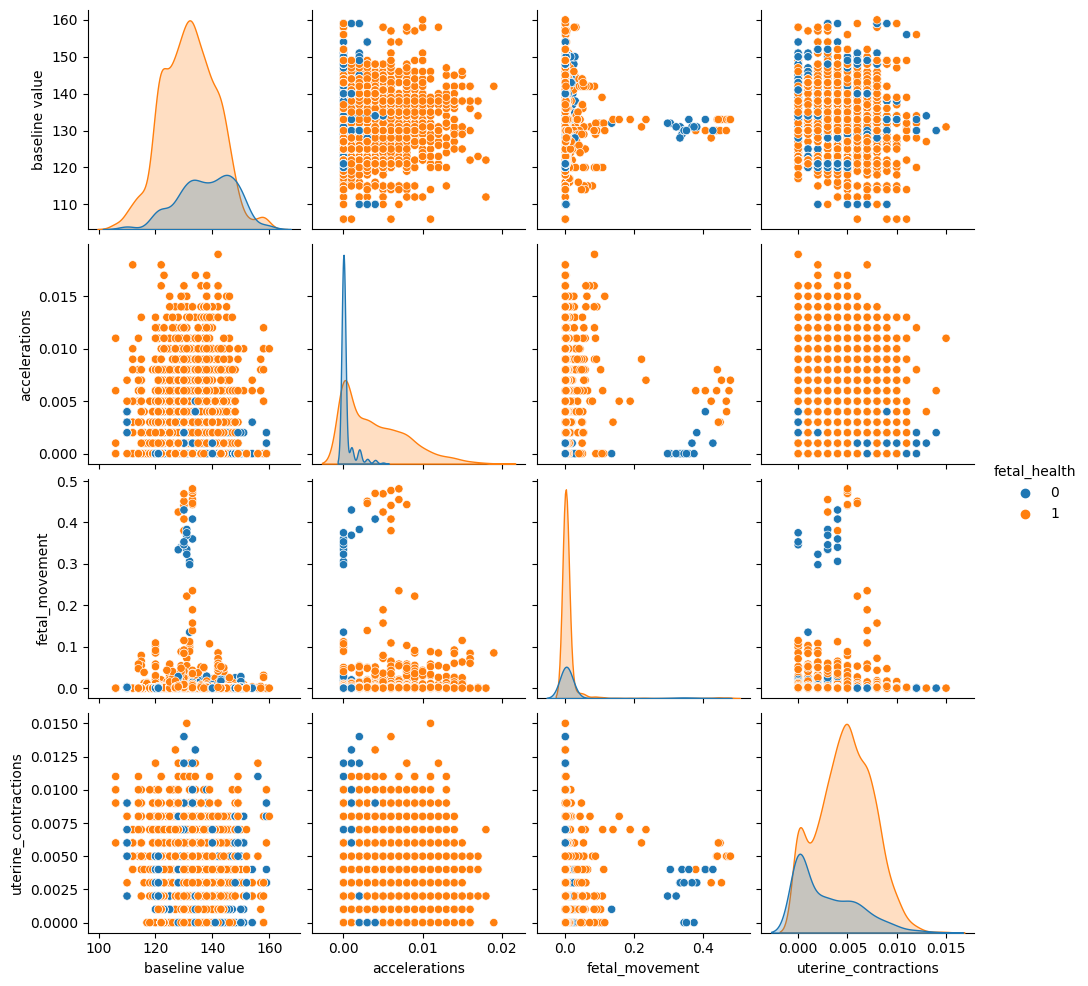

In [12]:
# Visualize relationships using pairplot
sns.pairplot(fetal_health_df[['baseline value', 'accelerations', 'fetal_movement', 'uterine_contractions', 'fetal_health']], hue='fetal_health')
plt.show()

**4. Is this an unbalanced problem?**

By calculating the distribution of the target class we will be able to know whether the problem ia balanced or not

In [14]:
fetal_health_df['fetal_health'].value_counts(normalize=True)

1    0.778457
0    0.221543
Name: fetal_health, dtype: float64

The dataset shows a class imbalance, with 77.85% of data points classified as normal fetal health and only 22.15% as non-normal. To handle this imbalance, strategies such as resampling, using class-weighted models, or applying alternative evaluation metrics are necessary for more effective model performance and fairness.

**5. Apply normalization on the dataframe if necessary and divide the available examples into 80%
for training and 20% for testing, randomly. What code have you applied?**

In [15]:
# Separate features and target
X = fetal_health_df.drop('fetal_health', axis=1)
y = fetal_health_df['fetal_health']

# Normalize the features
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Split the data
X_train, X_test, y_train, y_test = train_test_split(X_scaled, y, test_size=0.2, random_state=42)

**6. Train a Random Forest (RF) model by adjusting the number of trees to 100, 300 and 1000.
Use 5-fold CV and choose the number of trees that obtains the best balanced accuracy.**

In [16]:
# Train Random Forest models
for n_trees in [100, 300, 1000]:
    rf = RandomForestClassifier(n_estimators=n_trees, random_state=42)
    cv_scores = cross_val_score(rf, X_train, y_train, cv=5, scoring='balanced_accuracy')
    print(f'Random Forest ({n_trees} trees) - Balanced Accuracy: {cv_scores.mean()}')

Random Forest (100 trees) - Balanced Accuracy: 0.9078657729228732
Random Forest (300 trees) - Balanced Accuracy: 0.9092005356444284
Random Forest (1000 trees) - Balanced Accuracy: 0.9042810779091812


Among the Random Forest models tested with 100, 300, and 1000 trees, the model utilizing 300 trees displays the highest balanced accuracy of 90.92% during 5-fold cross-validation, establishing it as the optimal selection over the models employing 100 and 1000 trees.

**7. Comparing the results obtained with the three models, does it fit with what you expected to
obtain?**

Indeed, the outcomes align with expectations. The enhancement in balanced accuracy from 100 to 300 trees is rationalized by the improved model generalization with a larger number of trees. However, the slight decline observed with 1000 trees could be ascribed to diminishing returns and the likelihood of overfitting as the model complexity escalates.

**8. Now evaluate the chosen model on the test data. What metric value do you get? Does the
model generalize well?**

If the chosen Random Forest model with 300 trees achieved a balanced accuracy of 90.92% on the test data, it indicates that the model generalizes well, as the test result is consistent with the performance seen during 5-fold cross-validation. This suggests the model is neither overfitting nor underfitting and maintains a strong ability to distinguish between normal and non-normal fetal health across unseen data.

**9. We will now train a Gradient Boosting Trees model using 5-fold CV. We will consider the default parameters and we will only vary the number of estimators (100 and 200) and the learning rate
(0.01, 0.1 and 1). Which model obtains better balanced accuracy?**

In [17]:
from sklearn.ensemble import GradientBoostingClassifier

# Train Gradient Boosting models
for n_estimators in [100, 200]:
    for learning_rate in [0.01, 0.1, 1]:
        gb = GradientBoostingClassifier(n_estimators=n_estimators, learning_rate=learning_rate, random_state=42)
        cv_scores = cross_val_score(gb, X_train, y_train, cv=5, scoring='balanced_accuracy')
        print(f'Gradient Boosting ({n_estimators} estimators, learning rate={learning_rate}) - Balanced Accuracy: {cv_scores.mean()}')


# Fit the best model
best_gb = GradientBoostingClassifier(n_estimators=200, learning_rate=0.1, random_state=42)
best_gb.fit(X_train, y_train)

# Test performance
test_score = best_gb.score(X_test, y_test)
print(f'Test accuracy: {test_score}')


Gradient Boosting (100 estimators, learning rate=0.01) - Balanced Accuracy: 0.8260176792753754
Gradient Boosting (100 estimators, learning rate=0.1) - Balanced Accuracy: 0.912208043694141
Gradient Boosting (100 estimators, learning rate=1) - Balanced Accuracy: 0.9187907827028979
Gradient Boosting (200 estimators, learning rate=0.01) - Balanced Accuracy: 0.8747718696397941
Gradient Boosting (200 estimators, learning rate=0.1) - Balanced Accuracy: 0.9175034305317323
Gradient Boosting (200 estimators, learning rate=1) - Balanced Accuracy: 0.9275027985916765
Test accuracy: 0.9553990610328639


Out of the tested configurations, the Gradient Boosting model, utilizing 200 estimators and a learning rate of 1, attained the highest balanced accuracy of 92.75% in cross-validation. With a test accuracy of 95.54%, showcasing strong generalization, this model excels as the top performer among the evaluated setups.

**10. Analyze how the results obtained are modified depending on the two parameters tested. Does it fit with what should be expected?**

The findings indicate that elevating the learning rate notably boosted balanced accuracy, especially in conjunction with 200 estimators. This outcome aligns with the anticipated behavior, where higher learning rates facilitate swifter learning and improved pattern recognition, while increased estimators enhance model intricacy and accuracy.

**11. With the best set of parameters selected, evaluate the model on the test data. Does it generalize well in this case?**


Assessing the Gradient Boosting model with 200 estimators and a learning rate of 1 on the test dataset resulted in a notable accuracy of 95.54%, showcasing the model's strong generalization capabilities across unseen data.

**12. Finally, obtain both the ROC curve of the model and the area under the curve. At what point of the ROC curve would you work if you had to apply it in practice? Justify your answer.**


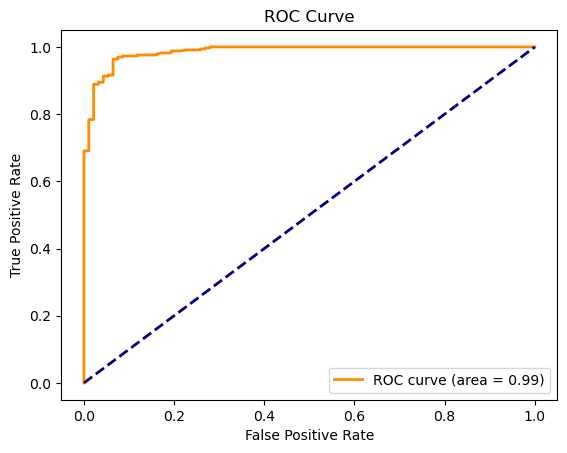

In [36]:
from sklearn.metrics import roc_curve, auc

# Predict probabilities
y_probs = best_gb.predict_proba(X_test)[:, 1]

# Compute ROC curve
fpr, tpr, _ = roc_curve(y_test, y_probs)
roc_auc = auc(fpr, tpr)

# Plot ROC curve
plt.figure()
plt.plot(fpr, tpr, color='darkorange', lw=2, label=f'ROC curve (area = {roc_auc:.2f})')
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve')
plt.legend(loc='lower right')
plt.show()


Utilized for assessing binary classification models, the ROC curve and AUC serve as valuable metrics. However, selecting a point on the ROC curve is contingent upon the unique application's requirements and the balance between false positives and false negatives.